# Figure 3: 
Regression of activity v metabolic rates

## Load data and shared style

Required files:
- batch_summary.csv
- signal_rate_summary.csv
- photeros.mplstyle
- figure_style.py

In [7]:
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

# Load shared style + palette
style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

# Load processed summary data
candidate_paths = [
    Path.cwd() / '../data/processed/batch_summary.csv',
    Path.cwd() / 'data/processed/batch_summary.csv',
    Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv'),
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find data/processed/batch_summary.csv')

agg_df = pd.read_csv(data_path)
reg_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

print(f'Shared style loaded from: {style_path}')
print(f'Loaded {len(reg_df)} rows for Figure 3 from: {data_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle
Loaded 58 rows for Figure 3 from: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


## Regress activity estimates against metabolic rate measures

In [8]:
# Merge activity estimates (signal rate) with metabolic rates
from scipy import stats

signal_rate_candidates = [
    Path.cwd() / '../data/processed/signal_rate_summary.csv',
    Path.cwd() / 'data/processed/signal_rate_summary.csv',
    Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/signal_rate_summary.csv'),
]

signal_rate_path = next((p.resolve() for p in signal_rate_candidates if p.exists()), None)
if signal_rate_path is None:
    raise FileNotFoundError('Could not find data/processed/signal_rate_summary.csv')

signal_df = pd.read_csv(signal_rate_path)

# Merge signal rate into cylinder rows by trial, brick, channel
cylinder_mask = reg_df['vessel'] == 'cylinder'
reg_df_cyl = reg_df[cylinder_mask].copy()
reg_df_non_cyl = reg_df[~cylinder_mask].copy()

merged_cyl = pd.merge(
    reg_df_cyl,
    signal_df[['trial', 'brick', 'channel', 'signal_rate']],
    on=['trial', 'brick', 'channel'],
    how='left',
)

# Non-cylinder rows have no courtship signal estimate
reg_df_non_cyl['signal_rate'] = 0.0
merged_df = pd.concat([merged_cyl, reg_df_non_cyl], ignore_index=True)

print(f'Loaded activity estimates from: {signal_rate_path}')
print(f'Merged rows: {len(merged_df)}')
print(f'Cylinder rows with signal_rate: {merged_df[merged_df["vessel"] == "cylinder"]["signal_rate"].notna().sum()}')

display(merged_df.head())

Loaded activity estimates from: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/signal_rate_summary.csv
Merged rows: 58
Cylinder rows with signal_rate: 8


,trial,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,A,M,temp_C,vessel,date,environment,notes,filtered,signal_rate
0,trial1,box3,Ch2,20.0,7.6,7.238095,8.546660,6.628954,9.384154,28.233,cylinder,10Nov2025,night,NaN,True,9.745342
1,trial1,box3,Ch3,20.0,6.5,7.222222,8.352764,6.475010,9.166227,28.233,cylinder,10Nov2025,night,NaN,True,0.981366
2,trial1,box3,Ch4,20.0,5.5,7.333333,7.555755,5.879572,8.323307,28.233,cylinder,10Nov2025,night,NaN,True,4.161491
3,trial3,box2,Ch2,20.0,4.9,4.900000,5.227565,3.677824,5.206443,26.750,cylinder,12Nov2025,night,"Ch2 closest to GoPro, Ch4 farthest from GoPro",True,0.174402
4,trial3,box2,Ch3,20.0,4.7,4.700000,3.558230,2.477428,3.507124,26.750,cylinder,12Nov2025,night,"Ch2 closest to GoPro, Ch4 farthest from GoPro",True,0.485232


## Original Figure 3: activity estimate and metabolic rate

This is the primary cylinder-only regression without temperature in the model.

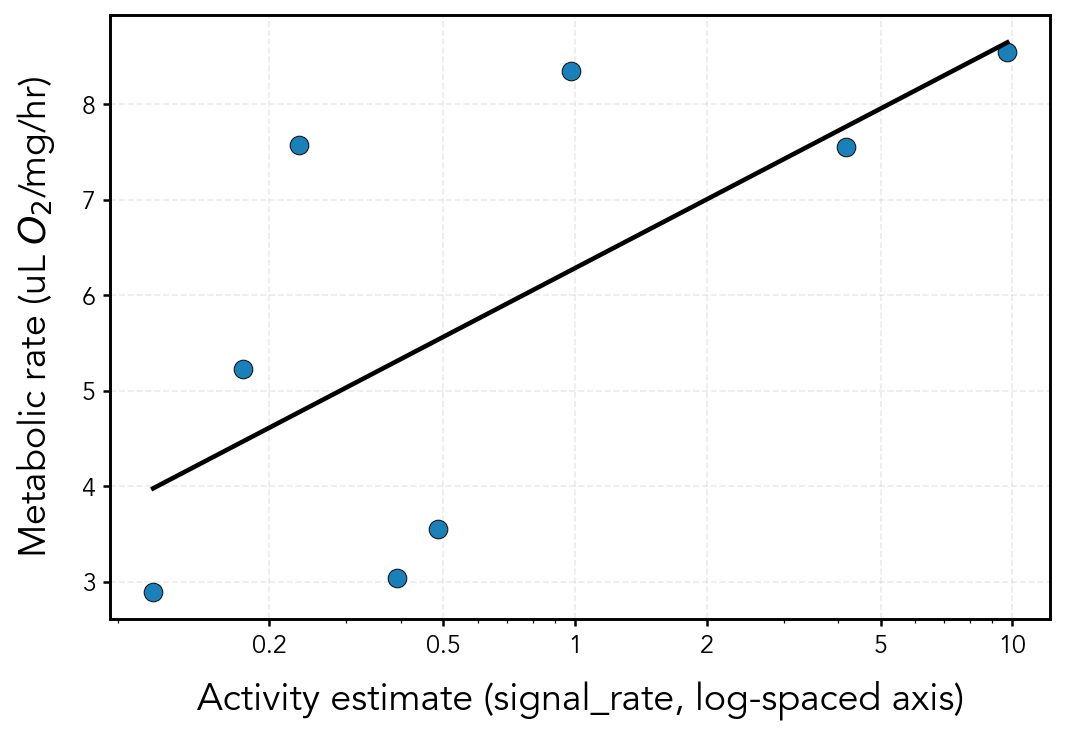

Original unadjusted regression summary (log10(signal_rate) -> RMR):
  slope: 2.3905
  intercept: 6.2853
  R^2: 0.4471
  p-value: 6.9859e-02
  std err: 1.0853


In [9]:
# Original Figure 3 regression: cylinder signal_rate vs metabolic rate (RMR)
# This keeps the original no-temperature analysis and figure.

cyl_df = merged_df[
    (merged_df['vessel'] == 'cylinder') &
    (merged_df['signal_rate'].notna()) &
    (merged_df['signal_rate'] > 0) &
    (merged_df['RMR'].notna())
].copy()

if cyl_df.empty:
    print('No cylinder data available for regression plotting.')
else:
    cyl_df['signal_rate_log10'] = np.log10(cyl_df['signal_rate'])

    slope, intercept, r_value, p_value, stderr = stats.linregress(
        cyl_df['signal_rate_log10'], cyl_df['RMR']
    )
    r2 = r_value ** 2

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    ax.scatter(
        cyl_df['signal_rate'],
        cyl_df['RMR'],
        s=80,
        color=DARK_BLUE,
        edgecolors='black',
        linewidth=0.5,
        alpha=0.9,
        zorder=3,
    )

    # Regression line in original x-space from model fit in log10-space.
    x_line = np.geomspace(cyl_df['signal_rate'].min(), cyl_df['signal_rate'].max(), 200)
    y_line = intercept + slope * np.log10(x_line)
    ax.plot(x_line, y_line, color='black', linewidth=2.2, zorder=4)

    ax.set_xscale('log')
    ax.set_xlabel('Activity estimate (signal_rate, log-spaced axis)', fontsize=18, labelpad=10)
    ax.set_ylabel('Metabolic rate (uL $O_2$/mg/hr)', fontsize=18, labelpad=12)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, linestyle='--', alpha=0.25)

    # Match comparative style: log spacing but plain (unlogged) numeric tick labels.
    tick_candidates = np.array([0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20], dtype=float)
    xmin = float(cyl_df['signal_rate'].min())
    xmax = float(cyl_df['signal_rate'].max())
    xticks = tick_candidates[(tick_candidates >= xmin * 0.95) & (tick_candidates <= xmax * 1.05)]
    if len(xticks) < 3:
        xticks = np.geomspace(xmin, xmax, min(5, len(cyl_df)))
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{t:g}' for t in xticks])

    plt.tight_layout()
    plt.show()

    print('Original unadjusted regression summary (log10(signal_rate) -> RMR):')
    print(f'  slope: {slope:.4f}')
    print(f'  intercept: {intercept:.4f}')
    print(f'  R^2: {r2:.4f}')
    print(f'  p-value: {p_value:.4e}')
    print(f'  std err: {stderr:.4f}')


In [10]:
# Original no-temperature regression statistics with confidence intervals + robust comparison
try:
    import statsmodels.api as sm
except ImportError:
    print('statsmodels is required for confidence intervals and robust regression.')
    print('Install with: pip install statsmodels')
else:
    if 'cyl_df' not in locals() or cyl_df.empty:
        print('No cylinder data available. Run the original regression plot cell first.')
    else:
        stats_df = cyl_df.copy()
        X = sm.add_constant(stats_df[['signal_rate_log10']])
        y = stats_df['RMR']

        ols_model = sm.OLS(y, X).fit()
        rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
        ols_ci = ols_model.conf_int(alpha=0.05)

        original_summary_table = pd.DataFrame({
            'model': ['OLS', 'RLM (HuberT)'],
            'n': [int(len(stats_df)), int(len(stats_df))],
            'slope_log10_signal_rate': [
                float(ols_model.params['signal_rate_log10']),
                float(rlm_model.params['signal_rate_log10']),
            ],
            'intercept': [
                float(ols_model.params['const']),
                float(rlm_model.params['const']),
            ],
            'slope_ci95_lower': [float(ols_ci.loc['signal_rate_log10', 0]), np.nan],
            'slope_ci95_upper': [float(ols_ci.loc['signal_rate_log10', 1]), np.nan],
            'intercept_ci95_lower': [float(ols_ci.loc['const', 0]), np.nan],
            'intercept_ci95_upper': [float(ols_ci.loc['const', 1]), np.nan],
            'r_squared': [float(ols_model.rsquared), np.nan],
            'p_value_slope': [float(ols_model.pvalues['signal_rate_log10']), np.nan],
        })

        print('Original regression statistics (activity -> metabolic rate; no temperature)')
        print('=' * 78)
        display(original_summary_table)

        print()
        print('Caption-ready sentence:')
        print(
            f"OLS regression of metabolic rate on log10(activity estimate) gave a slope of "
            f"{ols_model.params['signal_rate_log10']:.3f} "
            f"(95% CI {ols_ci.loc['signal_rate_log10', 0]:.3f} to {ols_ci.loc['signal_rate_log10', 1]:.3f}; "
            f"R^2={ols_model.rsquared:.3f}; p={ols_model.pvalues['signal_rate_log10']:.3e}; n={len(stats_df)})."
        )

        print()
        print('Robust comparison (HuberT):')
        print(
            f"Robust slope estimate = {rlm_model.params['signal_rate_log10']:.3f}, "
            f"intercept = {rlm_model.params['const']:.3f}."
        )


Original regression statistics (activity -> metabolic rate; no temperature)


,model,n,slope_log10_signal_rate,intercept,slope_ci95_lower,slope_ci95_upper,intercept_ci95_lower,intercept_ci95_upper,r_squared,p_value_slope
0,OLS,8,2.390477,6.285345,-0.265248,5.046201,4.521024,8.049666,0.44706,0.069859
1,RLM (HuberT),8,2.390477,6.285345,NaN,NaN,NaN,NaN,NaN,NaN



Caption-ready sentence:
OLS regression of metabolic rate on log10(activity estimate) gave a slope of 2.390 (95% CI -0.265 to 5.046; R^2=0.447; p=6.986e-02; n=8).

Robust comparison (HuberT):
Robust slope estimate = 2.390, intercept = 6.285.


## Temperature caveat for cylinder trials

This supplementary analysis keeps the same cylinder rows but colors points by temperature and fits `RMR ~ log10(signal_rate) + temp_C`.

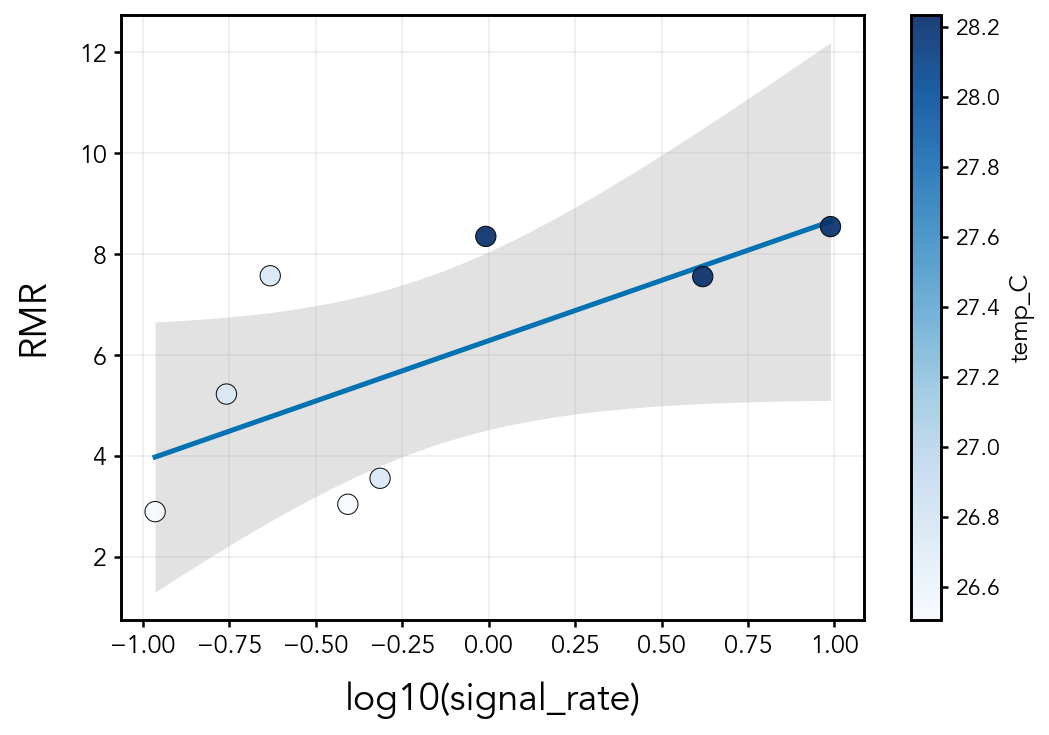

In [11]:
# Temperature-colored cylinder regression plot.
# The line is the unadjusted RMR ~ log10(signal_rate) fit, with points colored by temp_C.

if 'cyl_df' not in locals() or cyl_df.empty:
    print('No cylinder data available. Run the original regression plot cell first.')
else:
    temp_plot_df = cyl_df.dropna(subset=['temp_C']).copy()

    if temp_plot_df.empty:
        print('No cylinder rows with temperature available for plotting.')
    else:
        slope_temp_plot, intercept_temp_plot, _, _, _ = stats.linregress(
            temp_plot_df['signal_rate_log10'], temp_plot_df['RMR']
        )

        fig_temp, ax_temp = plt.subplots(figsize=(7.2, 5.0))

        scatter = ax_temp.scatter(
            temp_plot_df['signal_rate_log10'],
            temp_plot_df['RMR'],
            c=temp_plot_df['temp_C'],
            cmap='Blues',
            s=95,
            edgecolors='black',
            linewidth=0.5,
            alpha=0.92,
            zorder=3,
        )

        # Draw the unadjusted regression line with a 95% confidence band, matching ggplot geom_smooth(method='lm').
        x_obs = temp_plot_df['signal_rate_log10'].to_numpy(dtype=float)
        y_obs = temp_plot_df['RMR'].to_numpy(dtype=float)
        x_line = np.linspace(x_obs.min(), x_obs.max(), 200)
        y_line = intercept_temp_plot + slope_temp_plot * x_line

        n_obs = len(temp_plot_df)
        x_mean = x_obs.mean()
        ssx = np.sum((x_obs - x_mean) ** 2)
        residuals = y_obs - (intercept_temp_plot + slope_temp_plot * x_obs)
        residual_se = np.sqrt(np.sum(residuals ** 2) / (n_obs - 2))
        t_crit = stats.t.ppf(0.975, df=n_obs - 2)
        mean_se = residual_se * np.sqrt(1 / n_obs + (x_line - x_mean) ** 2 / ssx)

        ax_temp.fill_between(
            x_line,
            y_line - t_crit * mean_se,
            y_line + t_crit * mean_se,
            color='0.75',
            alpha=0.45,
            linewidth=0,
            zorder=1,
        )
        ax_temp.plot(x_line, y_line, color=DARK_BLUE, linewidth=2.4, zorder=2)

        ax_temp.set_xlabel('log10(signal_rate)', fontsize=18, labelpad=10)
        ax_temp.set_ylabel('RMR', fontsize=18, labelpad=12)
        ax_temp.tick_params(axis='both', labelsize=12)
        ax_temp.grid(True, linestyle='-', alpha=0.22)

        cbar = fig_temp.colorbar(scatter, ax=ax_temp)
        cbar.set_label('temp_C', fontsize=12)
        cbar.ax.tick_params(labelsize=11)

        plt.tight_layout()
        plt.show()


In [6]:
# Temperature-adjusted regression statistics: signal rate and temperature effects on RMR in cylinder data
try:
    import statsmodels.api as sm
except ImportError:
    print('statsmodels is required for confidence intervals and temperature-adjusted regression.')
    print('Install with: pip install statsmodels')
else:
    if 'cyl_df' not in locals() or cyl_df.empty:
        print('No cylinder data available. Run the original regression plot cell first.')
    else:
        temp_stats_df = cyl_df.dropna(subset=['temp_C']).copy()
        y = temp_stats_df['RMR']

        X_signal = sm.add_constant(temp_stats_df[['signal_rate_log10']])
        signal_model_for_temp = sm.OLS(y, X_signal).fit()

        X_temp = sm.add_constant(temp_stats_df[['signal_rate_log10', 'temp_C']])
        temp_model = sm.OLS(y, X_temp).fit()
        temp_ci = temp_model.conf_int(alpha=0.05)

        f_stat, f_p_value, df_diff = temp_model.compare_f_test(signal_model_for_temp)
        temp_signal_corr = temp_stats_df['signal_rate_log10'].corr(temp_stats_df['temp_C'])

        temp_coef_table = pd.DataFrame({
            'term': temp_model.params.index,
            'estimate': temp_model.params.values,
            'std_error': temp_model.bse.values,
            't_value': temp_model.tvalues.values,
            'p_value': temp_model.pvalues.values,
            'ci95_lower': temp_ci[0].values,
            'ci95_upper': temp_ci[1].values,
        })

        temp_model_summary = pd.DataFrame({
            'model': ['signal only', 'signal + temperature'],
            'n': [int(signal_model_for_temp.nobs), int(temp_model.nobs)],
            'r_squared': [float(signal_model_for_temp.rsquared), float(temp_model.rsquared)],
            'adj_r_squared': [float(signal_model_for_temp.rsquared_adj), float(temp_model.rsquared_adj)],
            'aic': [float(signal_model_for_temp.aic), float(temp_model.aic)],
        })

        temp_comparison = pd.DataFrame({
            'comparison': ['add temp_C to signal-rate model'],
            'f_stat': [float(f_stat)],
            'df_diff': [float(df_diff)],
            'p_value': [float(f_p_value)],
            'corr_log10_signal_rate_temp_C': [float(temp_signal_corr)],
        })

        adjusted_model = temp_model

        print('Temperature-adjusted OLS: RMR ~ log10(signal_rate) + temp_C')
        print('=' * 72)
        display(temp_coef_table)

        print()
        print('Model fit summary')
        print('=' * 72)
        display(temp_model_summary)

        print()
        print('Does temperature improve the signal-rate regression?')
        print('=' * 72)
        display(temp_comparison)

        print()
        print('Caption-ready sentence:')
        print(
            f"In cylinder trials, log10(signal_rate) and temp_C covaried strongly "
            f"(r={temp_signal_corr:.3f}). In a temperature-adjusted model, the signal-rate slope was "
            f"{temp_model.params['signal_rate_log10']:.3f} "
            f"(95% CI {temp_ci.loc['signal_rate_log10', 0]:.3f} to {temp_ci.loc['signal_rate_log10', 1]:.3f}, "
            f"p={temp_model.pvalues['signal_rate_log10']:.3e}; n={int(temp_model.nobs)}), "
            f"and the temperature coefficient was {temp_model.params['temp_C']:.3f} "
            f"(95% CI {temp_ci.loc['temp_C', 0]:.3f} to {temp_ci.loc['temp_C', 1]:.3f}, "
            f"p={temp_model.pvalues['temp_C']:.3e})."
        )


Temperature-adjusted OLS: RMR ~ log10(signal_rate) + temp_C


,term,estimate,std_error,t_value,p_value,ci95_lower,ci95_upper
0,const,-77.665355,40.825274,-1.902384,0.115509,-182.610063,27.279353
1,signal_rate_log10,-0.837951,1.797260,-0.466238,0.660652,-5.457955,3.782052
2,temp_C,3.059443,1.487658,2.056550,0.094849,-0.764704,6.883590



Model fit summary


,model,n,r_squared,adj_r_squared,aic
0,signal only,8,0.447060,0.354904,35.161684
1,signal + temperature,8,0.700446,0.580625,32.258037



Does temperature improve the signal-rate regression?


,comparison,f_stat,df_diff,p_value,corr_log10_signal_rate_temp_C
0,add temp_C to signal-rate model,4.229398,1.0,0.094849,0.873456



Caption-ready sentence:
In cylinder trials, log10(signal_rate) and temp_C covaried strongly (r=0.873). In a temperature-adjusted model, the signal-rate slope was -0.838 (95% CI -5.458 to 3.782, p=6.607e-01; n=8), and the temperature coefficient was 3.059 (95% CI -0.765 to 6.884, p=9.485e-02).


In [7]:
# Save Figure 3 to files
figures_dir = Path.cwd() / '../figures'
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    png_path = (figures_dir / 'Figure3_Regression.png').resolve()
    pdf_path = (figures_dir / 'Figure3_Regression.pdf').resolve()

    fig.savefig(png_path, dpi=600, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')

    print(f'Saved PNG: {png_path}')
    print(f'Saved PDF: {pdf_path}')
else:
    print('No original Figure 3 object found. Run the original regression plot cell first.')

if 'fig_temp' in locals():
    temp_png_path = (figures_dir / 'FigureS3_Temperature_Regression.png').resolve()
    temp_pdf_path = (figures_dir / 'FigureS3_Temperature_Regression.pdf').resolve()

    fig_temp.savefig(temp_png_path, dpi=600, bbox_inches='tight')
    fig_temp.savefig(temp_pdf_path, bbox_inches='tight')

    print(f'Saved temperature PNG: {temp_png_path}')
    print(f'Saved temperature PDF: {temp_pdf_path}')


Saved PNG: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure3_Regression.png
Saved PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure3_Regression.pdf


Saved temperature PNG: /Users/oakley/Documents/GitHub/signal_respirometry/figures/FigureS3_Temperature_Regression.png
Saved temperature PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/FigureS3_Temperature_Regression.pdf


## Power analysis

In [8]:
# Post hoc power analysis for the Figure 3 regression slope
# Uses Fisher z approximation for the correlation test (H0: rho = 0).
from scipy.stats import norm

alpha = 0.05
target_powers = [0.80, 0.90]

# Use OLS model if available; otherwise derive r and n from cyl_df
if 'ols_model' in locals():
    r2_obs = float(ols_model.rsquared)
    n_obs = int(ols_model.nobs)
    slope_sign = np.sign(float(ols_model.params['signal_rate_log10']))
    r_obs = slope_sign * np.sqrt(r2_obs)
elif 'cyl_df' in locals() and len(cyl_df) >= 4:
    x = cyl_df['signal_rate_log10'] if 'signal_rate_log10' in cyl_df.columns else np.log10(cyl_df['signal_rate'])
    y = cyl_df['RMR']
    _, _, r_val, _, _ = stats.linregress(x, y)
    r_obs = float(r_val)
    r2_obs = float(r_obs ** 2)
    n_obs = int(len(cyl_df))
else:
    raise RuntimeError('Need regression results first. Run Cells 5-7 before power analysis.')

if n_obs < 4:
    raise ValueError('Power approximation requires n >= 4.')

if abs(r_obs) >= 1.0:
    raise ValueError('Observed correlation magnitude is 1.0; power analysis is undefined.')

def approx_power_corr(n, r, alpha=0.05):
    # Fisher z under alternative: Z ~ N(delta, 1) where delta = sqrt(n-3)*atanh(r)
    zcrit = norm.ppf(1 - alpha / 2.0)
    delta = np.sqrt(n - 3.0) * np.arctanh(r)
    return (1 - norm.cdf(zcrit - delta)) + norm.cdf(-zcrit - delta)

achieved_power = approx_power_corr(n_obs, r_obs, alpha=alpha)

required_rows = []
for target in target_powers:
    required_n = None
    for n_try in range(4, 1001):
        pwr = approx_power_corr(n_try, r_obs, alpha=alpha)
        if pwr >= target:
            required_n = n_try
            break
    required_rows.append({
        'target_power': target,
        'required_n_total': required_n,
        'additional_n_needed': None if required_n is None else max(0, required_n - n_obs),
    })

power_summary = pd.DataFrame({
    'alpha': [alpha],
    'observed_n': [n_obs],
    'observed_r': [r_obs],
    'observed_R2': [r2_obs],
    'achieved_power_approx': [achieved_power],
})

required_df = pd.DataFrame(required_rows)

print('Power analysis for Figure 3 regression slope (approximate)')
print('=' * 72)
display(power_summary)
display(required_df)

print('\nInterpretation:')
print(
    f"With n={n_obs}, observed r={r_obs:.3f} (R^2={r2_obs:.3f}), approximate power is {achieved_power:.3f} at alpha={alpha:.2f}."
)

n80 = required_df.loc[required_df['target_power'] == 0.80, 'required_n_total'].iloc[0]
n90 = required_df.loc[required_df['target_power'] == 0.90, 'required_n_total'].iloc[0]
add80 = required_df.loc[required_df['target_power'] == 0.80, 'additional_n_needed'].iloc[0]
add90 = required_df.loc[required_df['target_power'] == 0.90, 'additional_n_needed'].iloc[0]

print('\nCaption-ready sentence:')
print(
    f"Post hoc power analysis (Fisher-z approximation) indicated {achieved_power:.2f} power "
    f"to detect the observed association (R^2={r2_obs:.2f}, n={n_obs}, alpha={alpha:.2f}); "
    f"approximately n={n80} ({add80} additional) and n={n90} ({add90} additional) "
    f"would be needed for 0.80 and 0.90 power, respectively."
 )

Power analysis for Figure 3 regression slope (approximate)


,alpha,observed_n,observed_r,observed_R2,achieved_power_approx
0,0.05,8,0.668626,0.44706,0.439418


,target_power,required_n_total,additional_n_needed
0,0.8,16,8
1,0.9,20,12



Interpretation:
With n=8, observed r=0.669 (R^2=0.447), approximate power is 0.439 at alpha=0.05.

Caption-ready sentence:
Post hoc power analysis (Fisher-z approximation) indicated 0.44 power to detect the observed association (R^2=0.45, n=8, alpha=0.05); approximately n=16 (8 additional) and n=20 (12 additional) would be needed for 0.80 and 0.90 power, respectively.


## Re-Run without filtering for Supplement

All-data merged rows: 71
Cylinder rows with usable signal_rate+RMR (all-data): 10


/var/folders/pg/rkmvtptx175d4dsj5fd6w4d40000gp/T/ipykernel_66485/1222435372.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_all.legend(frameon=False, fontsize=10, loc='upper left')


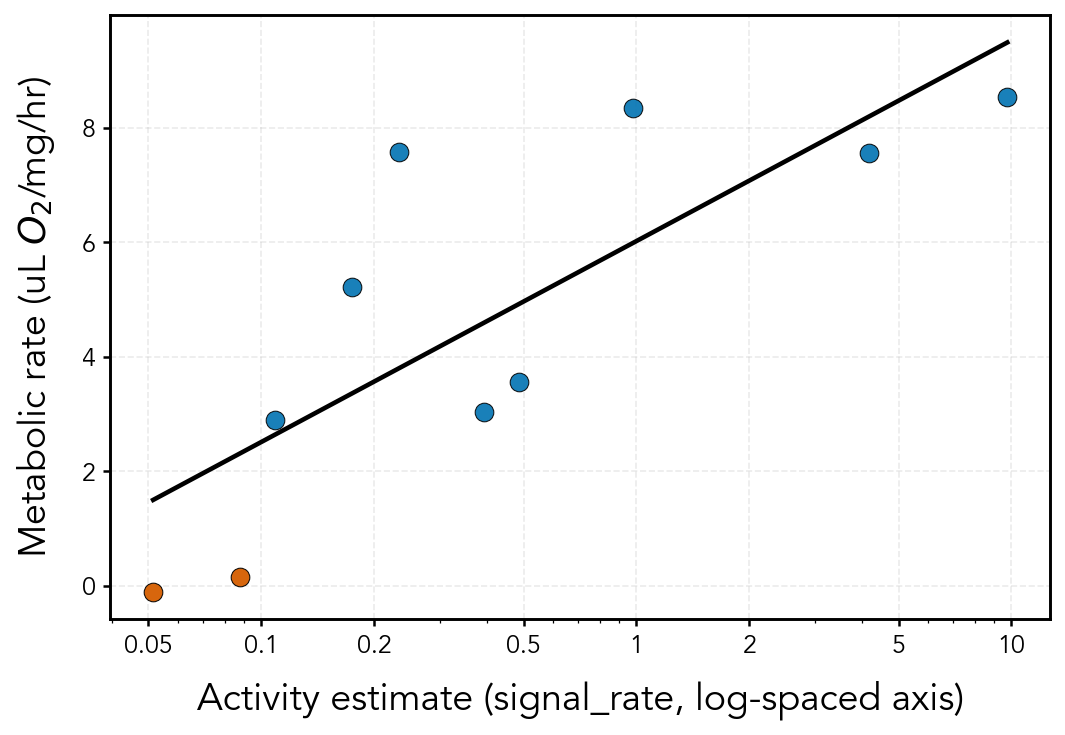

All-data regression summary (log10(signal_rate) -> RMR):
  slope: 3.5102
  intercept: 6.0225
  R^2: 0.6234
  p-value: 6.5949e-03
  std err: 0.9645

All-data regression statistics (activity -> metabolic rate)


,model,n,slope_log10_signal_rate,intercept,slope_ci95_lower,slope_ci95_upper,intercept_ci95_lower,intercept_ci95_upper,r_squared,p_value_slope
0,OLS,10,3.510164,6.022543,1.286033,5.734294,4.255903,7.789184,0.623442,0.006595
1,RLM (HuberT),10,3.560326,5.944255,NaN,NaN,NaN,NaN,NaN,NaN



All-data caption-ready sentence:
OLS regression on all rows (including unfiltered) gave slope 3.510 (95% CI 1.286 to 5.734; R^2=0.623; p=6.595e-03; n=10).

All-data robust comparison (HuberT):
Robust slope estimate = 3.560, intercept = 5.944.


In [9]:
# Re-run Figure 3 with all available rows (including rows marked filtered=False).
from scipy import stats

import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

if 'agg_df' not in locals():
    raise RuntimeError('Run Cell 3 first so agg_df is available.')

# Use ALL rows from batch summary (no filter exclusion).
reg_df_all = agg_df.copy()

# Locate signal-rate summary independently so this cell is self-contained.
signal_rate_candidates_all = [
    Path.cwd() / '../data/processed/signal_rate_summary.csv',
    Path.cwd() / 'data/processed/signal_rate_summary.csv',
    Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/signal_rate_summary.csv'),
]
signal_rate_path_all = next((p.resolve() for p in signal_rate_candidates_all if p.exists()), None)
if signal_rate_path_all is None:
    raise FileNotFoundError('Could not find data/processed/signal_rate_summary.csv')

signal_df_all = pd.read_csv(signal_rate_path_all)

# Same merge approach as the main Figure 3 analysis.
cylinder_mask_all = reg_df_all['vessel'] == 'cylinder'
reg_df_cyl_all = reg_df_all[cylinder_mask_all].copy()
reg_df_non_cyl_all = reg_df_all[~cylinder_mask_all].copy()

merged_cyl_all = pd.merge(
    reg_df_cyl_all,
    signal_df_all[['trial', 'brick', 'channel', 'signal_rate']],
    on=['trial', 'brick', 'channel'],
    how='left',
)

# Non-cylinder rows have no courtship signal estimate.
reg_df_non_cyl_all['signal_rate'] = 0.0
merged_df_all = pd.concat([merged_cyl_all, reg_df_non_cyl_all], ignore_index=True)

cyl_df_all = merged_df_all[
    (merged_df_all['vessel'] == 'cylinder') &
    (merged_df_all['signal_rate'].notna()) &
    (merged_df_all['signal_rate'] > 0) &
    (merged_df_all['RMR'].notna())
] .copy()

print(f'All-data merged rows: {len(merged_df_all)}')
print(f'Cylinder rows with usable signal_rate+RMR (all-data): {len(cyl_df_all)}')

if cyl_df_all.empty:
    print('No cylinder data available for all-data regression plotting.')
else:
    cyl_df_all['signal_rate_log10'] = np.log10(cyl_df_all['signal_rate'])

    # Plot + simple regression summary (same style as main figure).
    slope_all, intercept_all, r_value_all, p_value_all, stderr_all = stats.linregress(
        cyl_df_all['signal_rate_log10'], cyl_df_all['RMR']
    )
    r2_all = r_value_all ** 2

    fig_all, ax_all = plt.subplots(figsize=(7.2, 5.0))

    # Color points excluded from the main filtered plot in orange.
    included_df = cyl_df_all[cyl_df_all['filtered'] == True]
    excluded_df = cyl_df_all[cyl_df_all['filtered'] != True]

    ax_all.scatter(
        included_df['signal_rate'],
        included_df['RMR'],
        s=80,
        color=DARK_BLUE,
        edgecolors='black',
        linewidth=0.5,
        alpha=0.9,
        zorder=3,
    )
    if not excluded_df.empty:
        ax_all.scatter(
            excluded_df['signal_rate'],
            excluded_df['RMR'],
            s=80,
            color=DARK_ORANGE,
            edgecolors='black',
            linewidth=0.5,
            alpha=0.95,
            zorder=4,
        )

    x_line_all = np.geomspace(cyl_df_all['signal_rate'].min(), cyl_df_all['signal_rate'].max(), 200)
    y_line_all = intercept_all + slope_all * np.log10(x_line_all)
    ax_all.plot(x_line_all, y_line_all, color='black', linewidth=2.2, zorder=5)

    ax_all.set_xscale('log')
    ax_all.set_xlabel('Activity estimate (signal_rate, log-spaced axis)', fontsize=18, labelpad=10)
    ax_all.set_ylabel('Metabolic rate (uL $O_2$/mg/hr)', fontsize=18, labelpad=12)
    ax_all.tick_params(axis='both', labelsize=12)
    ax_all.grid(True, linestyle='--', alpha=0.25)

    tick_candidates_all = np.array([0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20], dtype=float)
    xmin_all = float(cyl_df_all['signal_rate'].min())
    xmax_all = float(cyl_df_all['signal_rate'].max())
    xticks_all = tick_candidates_all[
        (tick_candidates_all >= xmin_all * 0.95) & (tick_candidates_all <= xmax_all * 1.05)
    ]
    if len(xticks_all) < 3:
        xticks_all = np.geomspace(xmin_all, xmax_all, min(5, len(cyl_df_all)))
    ax_all.set_xticks(xticks_all)
    ax_all.set_xticklabels([f'{t:g}' for t in xticks_all])
    ax_all.legend(frameon=False, fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.show()

    print('All-data regression summary (log10(signal_rate) -> RMR):')
    print(f'  slope: {slope_all:.4f}')
    print(f'  intercept: {intercept_all:.4f}')
    print(f'  R^2: {r2_all:.4f}')
    print(f'  p-value: {p_value_all:.4e}')
    print(f'  std err: {stderr_all:.4f}')

    # Same richer stats block (OLS + robust model).
    X_all = sm.add_constant(cyl_df_all['signal_rate_log10'])
    y_all = cyl_df_all['RMR']

    ols_model_all = sm.OLS(y_all, X_all).fit()
    rlm_model_all = sm.RLM(y_all, X_all, M=sm.robust.norms.HuberT()).fit()
    ols_ci_all = ols_model_all.conf_int(alpha=0.05)

    summary_table_all = pd.DataFrame({
        'model': ['OLS', 'RLM (HuberT)'],
        'n': [int(len(cyl_df_all)), int(len(cyl_df_all))],
        'slope_log10_signal_rate': [
            float(ols_model_all.params['signal_rate_log10']),
            float(rlm_model_all.params['signal_rate_log10']),
        ],
        'intercept': [
            float(ols_model_all.params['const']),
            float(rlm_model_all.params['const']),
        ],
        'slope_ci95_lower': [float(ols_ci_all.loc['signal_rate_log10', 0]), np.nan],
        'slope_ci95_upper': [float(ols_ci_all.loc['signal_rate_log10', 1]), np.nan],
        'intercept_ci95_lower': [float(ols_ci_all.loc['const', 0]), np.nan],
        'intercept_ci95_upper': [float(ols_ci_all.loc['const', 1]), np.nan],
        'r_squared': [float(ols_model_all.rsquared), np.nan],
        'p_value_slope': [float(ols_model_all.pvalues['signal_rate_log10']), np.nan],
    })

    print('\nAll-data regression statistics (activity -> metabolic rate)')
    print('=' * 70)
    display(summary_table_all)

    print('\nAll-data caption-ready sentence:')
    print(
        f"OLS regression on all rows (including unfiltered) gave slope "
        f"{ols_model_all.params['signal_rate_log10']:.3f} "
        f"(95% CI {ols_ci_all.loc['signal_rate_log10', 0]:.3f} to "
        f"{ols_ci_all.loc['signal_rate_log10', 1]:.3f}; "
        f"R^2={ols_model_all.rsquared:.3f}; "
        f"p={ols_model_all.pvalues['signal_rate_log10']:.3e}; n={len(cyl_df_all)})."
    )

    print('\nAll-data robust comparison (HuberT):')
    print(
        f"Robust slope estimate = {rlm_model_all.params['signal_rate_log10']:.3f}, "
        f"intercept = {rlm_model_all.params['const']:.3f}."
    )